# Cellpose low-convexity cell segmentation pipeline

- loading images and optional ground-truth masks
- preprocessing
- Cellpose baseline + parameter sweep
- mask-level feature extraction
- instance matching to ground truth
- Dice / IoU evaluation ？
- optional random forest mask-quality modeling (not yet)
- lightweight post-processing and before/after comparison (not yet)

You can run it on a single image first, then switch to a folder of images.

## 1. Imports

In [ ]:

import os
import json
import math
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff

from cellpose import models
from cellpose.io import imread

from skimage import exposure, filters, morphology, measure, segmentation, util
from skimage.measure import regionprops, label
from scipy import ndimage as ndi


try:
    import napari
    HAS_NAPARI = True
except Exception:
    HAS_NAPARI = False

plt.rcParams["figure.figsize"] = (8, 8)
from skimage.transform import resize

## 2. Configuration

Edit this block before running.  
You can point `INPUT_PATH` to either a single image file or a folder.

If using a folder, make sure image and GT filenames share the same stem.

In [2]:
"""INPUT_PATH = "/Users/wendywang/Downloads/MP6843_img_full/F01_120w1.TIF"  

imgs = imread(INPUT_PATH)

viewer = napari.Viewer()

viewer.add_image(imgs)
napari.run()"""

'INPUT_PATH = "/Users/wendywang/Downloads/MP6843_img_full/F01_120w1.TIF"  \n\nimgs = imread(INPUT_PATH)\n\nviewer = napari.Viewer()\n\nviewer.add_image(imgs)\nnapari.run()'

In [ ]:

# User config

INPUT_PATH = "/Users/wendywang/Downloads/02604/project_cellpose/MP6843_img_full/F01_120w1.TIF" 
GT_PATH = "/Users/wendywang/Downloads/02604/project_cellpose/MP6843_seg/F01_120_GT_01.tif"
SAVE_ROOT = "./results_cellpose" #where you want to save the result, if save to current working folder: ./ or adjust based on what ever folder you want


USE_GPU = False
MODEL_TYPE = "cyto3"  # can try "cyto3", "cyto"

# Preprocessing
DO_NORMALIZE = True
DO_BACKGROUND_SUBTRACT = False
BACKGROUND_SIGMA = 30
DO_DENOISE = False
DENOISE_SIGMA = 1.0

# Baseline Cellpose parameters
BASELINE_CELL_DIAMETER = 30
BASELINE_CELLPROB_THRESHOLD = 0.0
BASELINE_FLOW_THRESHOLD = 0.4

# Parameter sweep and adjust according
RUN_SWEEP = True
SWEEP_DIAMETERS = [30]
SWEEP_CELLPROB_THRESHOLDS = [-2.0, 0.0]
SWEEP_FLOW_THRESHOLDS = [0.2]

# Post-processing
POSTPROCESS_REMOVE_SMALL_OBJECTS = True
MIN_OBJECT_SIZE = 50
POSTPROCESS_FILL_HOLES = True
MAX_HOLE_SIZE = 30


# Visualization
SHOW_NAPARI = False
SHOW_MATPLOTLIB = True

# For grayscale images, keep CHANNEL_AXIS = None.
# For RGB/multi-channel images, set CHANNEL_AXIS accordingly and adjust preprocess_image if needed.
CHANNEL_AXIS = None

## 3. Utility functions

In [ ]:

VALID_EXTS = {".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp"}

#create dir if not exist
def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

#check is the file an image?
def is_image_file(path):
    return Path(path).suffix.lower() in VALID_EXTS

#build image list
def list_images(path_like):
    p = Path(path_like)
    if p.is_file():
        if not is_image_file(p):
            raise ValueError(f"Unsupported image file: {p}")
        return [str(p)]
    elif p.is_dir():
        files = sorted([str(x) for x in p.iterdir() if x.is_file() and is_image_file(x)])
        if not files:
            raise ValueError(f"No image files found in folder: {p}")
        return files
    else:
        raise FileNotFoundError(f"Path not found: {p}")

# returns the filename without extension use for future naming
def stem(path):
    return Path(path).stem

#import gt image mask
def maybe_find_gt(img_path, gt_path):
    if not gt_path:
        return None

    gt_path = str(gt_path).strip()
    p = Path(gt_path)

    if p.is_file():
        return str(p)

    if p.is_dir():
        s = stem(img_path)
        matches = [x for x in p.iterdir() if x.is_file() and x.stem == s and is_image_file(x)]
        if matches:
            return str(matches[0])

    return None

#convert img to float, so we have consistent image for later process
def to_float01(img):
    img = np.asarray(img)

    if img.dtype.kind in "ui":
        maxv = np.iinfo(img.dtype).max
        img = img.astype(np.float32)
        if maxv > 0:
            img = img / maxv
    else:
        img = img.astype(np.float32)

    return img

#rescale intensity
def normalize_percentile(img, p_low=1, p_high=99):
    lo, hi = np.percentile(img, [p_low, p_high])
    out = np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)
    return out.astype(np.float32)

#some image may have uneven illumination or haze-like background so we smooth and substract it
def subtract_background(img, sigma=30):
    bg = filters.gaussian(img, sigma=sigma, preserve_range=True)
    out = img - bg
    out = out - out.min()
    if out.max() > 0:
        out = out / out.max()
    return out.astype(np.float32)


# instead of manually calling several preprocessing steps every time
# this standardizes the full image-prep stage
def preprocess_image(img):
    img = np.asarray(img)
    if img.ndim == 3 and CHANNEL_AXIS is None:
        # if RGB-like, convert to grayscale by mean
        if img.shape[-1] in (3, 4):
            img = img[..., :3].mean(axis=-1)
    img = to_float01(img)

    if DO_NORMALIZE:
        img = normalize_percentile(img)

    if DO_BACKGROUND_SUBTRACT:
        img = subtract_background(img, sigma=BACKGROUND_SIGMA)

    if DO_DENOISE:
        img = filters.gaussian(img, sigma=DENOISE_SIGMA, preserve_range=True)

    return img.astype(np.float32)

# no need to say more
def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

#visualization by drawing mask boundaries
def overlay_boundaries(image, mask):
    image = np.asarray(image)
    mask = np.asarray(mask)

    if image.shape[:2] != mask.shape[:2]:
        raise ValueError(
            f"Image shape {image.shape[:2]} and mask shape {mask.shape[:2]} do not match"
        )

    img = image.astype(np.float32)

    if img.ndim == 2:
        pass
    elif img.ndim == 3:
        if img.shape[-1] == 1:
            img = img[..., 0]
        elif img.shape[0] == 1:
            img = img[0]
        elif img.shape[-1] in (3, 4):
            img = img[..., :3].mean(axis=-1)
        else:
            raise ValueError(f"Unsupported image shape for overlay: {img.shape}")
    else:
        raise ValueError(f"Unsupported image ndim for overlay: {img.ndim}")

    if img.max() > img.min():
        img = (img - img.min()) / (img.max() - img.min())
    else:
        img = np.zeros_like(img, dtype=np.float32)

    over = np.stack([img, img, img], axis=-1)

    boundaries = segmentation.find_boundaries(mask, mode="outer")

    over[..., 0][boundaries] = 1.0
    over[..., 1][boundaries] = 0.0
    over[..., 2][boundaries] = 0.0

    return np.clip(over, 0, 1)

# no need to say more as well?
def save_overlay_png(image, mask, path, title=None):
    over = overlay_boundaries(image, mask)
    plt.figure(figsize=(7, 7))
    plt.imshow(over, cmap="gray")
    if title:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()

# resize mask if it's diff from img shape
# might influence quantification result need to modify? maybe
def resize_label_mask(mask, target_shape):
    return resize(
        mask,
        target_shape,
        order=0,
        preserve_range=True,
        anti_aliasing=False
    ).astype(mask.dtype)

# clear mask label and dimension and shape
def sanitize_label_mask(mask):
    mask = np.asarray(mask)

    # Case 1: already 2D
    if mask.ndim == 2:
        return mask

    # Case 2: singleton dimension like (1, H, W) or (H, W, 1)
    if mask.ndim == 3:
        if mask.shape[0] == 1:
            return mask[0]
        if mask.shape[-1] == 1:
            return mask[..., 0]

        # Case 3: RGB-like mask (H, W, 3) or (H, W, 4)
        if mask.shape[-1] in (3, 4):
            # If channels are identical, keep one channel
            if np.all(mask[..., 0] == mask[..., 1]) and np.all(mask[..., 0] == mask[..., 2]):
                return mask[..., 0]

            # Otherwise convert nonzero pixels into foreground labels
            # This is only safe if GT is binary-style coloring
            return (np.any(mask[..., :3] > 0, axis=-1)).astype(np.int32)

    raise ValueError(f"Unsupported GT mask shape: {mask.shape}")

## 4. Segmentation and post-processing functions

In [ ]:
# runs Cellpose on one image with one set of parameters.
def run_cellpose_single(img, diameter, cellprob_threshold, flow_threshold, model_type=MODEL_TYPE, use_gpu=USE_GPU):
    model = models.CellposeModel(gpu=use_gpu, model_type=model_type)
    masks, flows, styles = model.eval(
        img,
        diameter=diameter,
        cellprob_threshold=cellprob_threshold,
        flow_threshold=flow_threshold,
    )
    return masks, flows, styles

# clean up and preserve instance: that clean up tiny noise and little holes
def postprocess_instance_masks(mask):

    cleaned = np.zeros_like(mask, dtype=np.int32)
    next_id = 1

    for lab in np.unique(mask):
        if lab == 0:
            continue
        obj = mask == lab

        if POSTPROCESS_FILL_HOLES:
            obj = morphology.remove_small_holes(obj, area_threshold=MAX_HOLE_SIZE)

        if POSTPROCESS_REMOVE_SMALL_OBJECTS:
            obj = morphology.remove_small_objects(obj, min_size=MIN_OBJECT_SIZE)

        obj = np.asarray(obj, dtype=bool)
        if obj.sum() == 0:
            continue

        # In case object split during cleaning, keep connected components as separate instances
        cc = measure.label(obj)
        for sub_lab in np.unique(cc):
            if sub_lab == 0:
                continue
            sub = cc == sub_lab
            if sub.sum() == 0:
                continue
            cleaned[sub] = next_id
            next_id += 1

    return cleaned

## 5. Metrics and instance matching

In [ ]:
# computes Dice coefficient between two binary masks
def binary_dice(a, b):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    denom = a.sum() + b.sum()
    return (2 * inter / denom) if denom > 0 else 1.0

# computes Intersection over Union
def binary_iou(a, b):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return (inter / union) if union > 0 else 1.0

# returns all object labels except background
def mask_to_instances(mask):
    labels = np.unique(mask)
    labels = labels[labels != 0]
    return labels

# renumbers mask labels so they become consecutive
def relabel_sequential(mask):
    out = np.zeros_like(mask, dtype=np.int32)
    for i, lab in enumerate(mask_to_instances(mask), start=1):
        out[mask == lab] = i
    return out

# for each predicted object, finds the GT object with the highest overlap
def object_match_table(pred_mask, gt_mask):
    pred_mask = relabel_sequential(pred_mask)
    gt_mask = relabel_sequential(gt_mask)

    pred_labels = mask_to_instances(pred_mask)
    gt_labels = mask_to_instances(gt_mask)

    rows = []

    for pl in pred_labels:
        pred_obj = pred_mask == pl
        best_gt = 0
        best_iou = 0.0
        best_dice = 0.0

        for gl in gt_labels:
            gt_obj = gt_mask == gl
            iou = binary_iou(pred_obj, gt_obj)
            if iou > best_iou:
                best_iou = iou
                best_dice = binary_dice(pred_obj, gt_obj)
                best_gt = gl

        rows.append({
            "pred_label": int(pl),
            "matched_gt_label": int(best_gt),
            "best_iou": float(best_iou),
            "best_dice": float(best_dice),
        })

    return pd.DataFrame(rows)

# whole image matrics
def image_level_metrics(pred_mask, gt_mask):
    pred_bin = pred_mask > 0
    gt_bin = gt_mask > 0
    return {
        "image_dice_binary": float(binary_dice(pred_bin, gt_bin)),
        "image_iou_binary": float(binary_iou(pred_bin, gt_bin)),
        "n_pred_instances": int(len(mask_to_instances(pred_mask))),
        "n_gt_instances": int(len(mask_to_instances(gt_mask))),
    }

## 6. Feature extraction

In [ ]:
# shape and intensity feature
def compute_object_features(mask, image):
    image = np.asarray(image)
    mask = relabel_sequential(mask)

    rows = []
    for region in regionprops(mask, intensity_image=image):
        lab = int(region.label)
        area = float(region.area)
        perimeter = float(region.perimeter) if region.perimeter is not None else 0.0
        convex_area = float(region.convex_area) if hasattr(region, "convex_area") else np.nan
        solidity = float(region.solidity) if hasattr(region, "solidity") else np.nan
        eccentricity = float(region.eccentricity) if hasattr(region, "eccentricity") else np.nan
        major_axis_length = float(region.major_axis_length) if hasattr(region, "major_axis_length") else np.nan
        minor_axis_length = float(region.minor_axis_length) if hasattr(region, "minor_axis_length") else np.nan
        mean_intensity = float(region.mean_intensity) if hasattr(region, "mean_intensity") else np.nan

        circularity = (4 * math.pi * area / (perimeter ** 2 + 1e-8)) if perimeter > 0 else np.nan
        convexity = (area / convex_area) if convex_area and convex_area > 0 else np.nan
        bbox_area = float((region.bbox[2] - region.bbox[0]) * (region.bbox[3] - region.bbox[1]))
        extent = (area / bbox_area) if bbox_area > 0 else np.nan

        obj = mask == lab
        skeleton = morphology.skeletonize(obj)
        skeleton_length = float(skeleton.sum())

        boundary = segmentation.find_boundaries(obj, mode="outer")
        boundary_edge_strength = float(filters.sobel(image)[boundary].mean()) if boundary.any() else 0.0

        rows.append({
            "pred_label": lab,
            "area": area,
            "perimeter": perimeter,
            "convex_area": convex_area,
            "convexity": convexity,
            "solidity": solidity,
            "eccentricity": eccentricity,
            "major_axis_length": major_axis_length,
            "minor_axis_length": minor_axis_length,
            "circularity": circularity,
            "bbox_area": bbox_area,
            "extent": extent,
            "skeleton_length": skeleton_length,
            "mean_intensity": mean_intensity,
            "boundary_edge_strength": boundary_edge_strength,
        })

    return pd.DataFrame(rows)

# add Cellpose-derived confidence-like values to each object like mean cell prob 
#but currently not working still fixing
def attach_cellpose_confidence_features(df, mask, flows):

    out = df.copy()
    prob_map = None

    if isinstance(flows, (list, tuple)) and len(flows) > 2:
        arr = np.asarray(flows[2])
        if arr.ndim >= 2:
            prob_map = arr

    if prob_map is None:
        out["mean_cellprob"] = np.nan
        out["max_cellprob"] = np.nan
        return out

    if prob_map.ndim > 2:
        prob_map = np.squeeze(prob_map)
        if prob_map.ndim > 2:
            prob_map = prob_map[0]

    mean_probs = []
    max_probs = []
    for lab in out["pred_label"]:
        obj = mask == int(lab)
        vals = prob_map[obj]
        mean_probs.append(float(np.mean(vals)) if vals.size > 0 else np.nan)
        max_probs.append(float(np.max(vals)) if vals.size > 0 else np.nan)

    out["mean_cellprob"] = mean_probs
    out["max_cellprob"] = max_probs
    return out

## 7. Single-run pipeline

In [ ]:

def run_pipeline_on_image(
    img_path,
    gt_path=None,
    save_root=SAVE_ROOT,
    diameter=BASELINE_CELL_DIAMETER,
    cellprob_threshold=BASELINE_CELLPROB_THRESHOLD,
    flow_threshold=BASELINE_FLOW_THRESHOLD,
    model_type=MODEL_TYPE,
    use_gpu=USE_GPU,
    apply_postprocess=True,
):
    img_name = stem(img_path)
    run_name = f"d{diameter}_cp{cellprob_threshold}_ft{flow_threshold}"
    out_dir = os.path.join(save_root, img_name, run_name)
    ensure_dir(out_dir)

    raw_img = imread(img_path)
    proc_img = preprocess_image(raw_img)

    pred_mask, flows, styles = run_cellpose_single(
        proc_img,
        diameter=diameter,
        cellprob_threshold=cellprob_threshold,
        flow_threshold=flow_threshold,
        model_type=model_type,
        use_gpu=use_gpu,
    )

    pred_mask = relabel_sequential(pred_mask)
    pred_mask_post = postprocess_instance_masks(pred_mask) if apply_postprocess else pred_mask.copy()

    # Save masks
    tiff.imwrite(os.path.join(out_dir, "image_preprocessed.tif"), proc_img.astype(np.float32))
    tiff.imwrite(os.path.join(out_dir, "pred_mask_raw.tif"), pred_mask.astype(np.int32))
    tiff.imwrite(os.path.join(out_dir, "pred_mask_post.tif"), pred_mask_post.astype(np.int32))

    save_overlay_png(proc_img, pred_mask, os.path.join(out_dir, "overlay_raw.png"), title=f"{img_name} raw")
    save_overlay_png(proc_img, pred_mask_post, os.path.join(out_dir, "overlay_post.png"), title=f"{img_name} post")

    params = {
        "img_path": img_path,
        "gt_path": gt_path,
        "diameter": diameter,
        "cellprob_threshold": cellprob_threshold,
        "flow_threshold": flow_threshold,
        "model_type": model_type,
        "use_gpu": use_gpu,
        "apply_postprocess": apply_postprocess,
    }
    save_json(params, os.path.join(out_dir, "params.json"))

    # Features
    feat_raw = compute_object_features(pred_mask, proc_img)
    feat_raw = attach_cellpose_confidence_features(feat_raw, pred_mask, flows)
    feat_raw["image_name"] = img_name
    feat_raw["run_name"] = run_name
    feat_raw["postprocess"] = False

    feat_post = compute_object_features(pred_mask_post, proc_img)
    feat_post["mean_cellprob"] = np.nan
    feat_post["max_cellprob"] = np.nan
    feat_post["image_name"] = img_name
    feat_post["run_name"] = run_name
    feat_post["postprocess"] = True

    raw_match_df = None
    post_match_df = None
    image_metrics_raw = {}
    image_metrics_post = {}



    if gt_path:
        gt_mask = imread(gt_path)
        gt_mask = sanitize_label_mask(gt_mask)

        if gt_mask.shape[:2] != proc_img.shape[:2]:
            print(f"Resizing GT from {gt_mask.shape[:2]} to {proc_img.shape[:2]}")
            gt_mask = resize_label_mask(gt_mask, proc_img.shape[:2])

        gt_mask = relabel_sequential(gt_mask)

        tiff.imwrite(os.path.join(out_dir, "gt_mask.tif"), gt_mask.astype(np.int32))
        save_overlay_png(proc_img, gt_mask, os.path.join(out_dir, "overlay_gt.png"), title=f"{img_name} GT")
        
        raw_match_df = object_match_table(pred_mask, gt_mask)
        post_match_df = object_match_table(pred_mask_post, gt_mask)

        feat_raw = feat_raw.merge(raw_match_df, on="pred_label", how="left")
        feat_post = feat_post.merge(post_match_df, on="pred_label", how="left")

        feat_raw["quality_good"] = (feat_raw["best_dice"] >= QUALITY_LABEL_DICE_THRESHOLD).astype(int)
        feat_post["quality_good"] = (feat_post["best_dice"] >= QUALITY_LABEL_DICE_THRESHOLD).astype(int)

        image_metrics_raw = image_level_metrics(pred_mask, gt_mask)
        image_metrics_post = image_level_metrics(pred_mask_post, gt_mask)

        save_json(image_metrics_raw, os.path.join(out_dir, "image_metrics_raw.json"))
        save_json(image_metrics_post, os.path.join(out_dir, "image_metrics_post.json"))

    feat_raw.to_csv(os.path.join(out_dir, "features_raw.csv"), index=False)
    feat_post.to_csv(os.path.join(out_dir, "features_post.csv"), index=False)

    return {
        "img_path": img_path,
        "gt_path": gt_path,
        "proc_img": proc_img,
        "pred_mask_raw": pred_mask,
        "pred_mask_post": pred_mask_post,
        "features_raw": feat_raw,
        "features_post": feat_post,
        "image_metrics_raw": image_metrics_raw,
        "image_metrics_post": image_metrics_post,
        "out_dir": out_dir,
    }

## 8. Run a single baseline (tester)

In [9]:

ensure_dir(SAVE_ROOT)

image_files = list_images(INPUT_PATH)
single_img = image_files[0]
single_gt = maybe_find_gt(single_img, GT_PATH)

single_result = run_pipeline_on_image(
    img_path=single_img,
    gt_path=single_gt,
    save_root=SAVE_ROOT,
    diameter=BASELINE_CELL_DIAMETER,
    cellprob_threshold=BASELINE_CELLPROB_THRESHOLD,
    flow_threshold=BASELINE_FLOW_THRESHOLD,
    model_type=MODEL_TYPE,
    use_gpu=USE_GPU,
    apply_postprocess=True,
)

print("Saved to:", single_result["out_dir"])
if single_result["image_metrics_raw"]:
    print("Raw image metrics:", single_result["image_metrics_raw"])
    print("Post image metrics:", single_result["image_metrics_post"])

single_result["features_post"].head()

model_type argument is not used in v4.0.1+. Ignoring this argument...


Resizing GT from (520, 696) to (1040, 1392)
Saved to: ./results_cellpose/F01_120w1/d30_cp0.0_ft0.4
Raw image metrics: {'image_dice_binary': 0.954175796012807, 'image_iou_binary': 0.912367291151823, 'n_pred_instances': 92, 'n_gt_instances': 9}
Post image metrics: {'image_dice_binary': 0.9542300876011998, 'image_iou_binary': 0.9124665725105581, 'n_pred_instances': 92, 'n_gt_instances': 9}


,pred_label,area,perimeter,convex_area,convexity,solidity,eccentricity,major_axis_length,minor_axis_length,circularity,...,boundary_edge_strength,mean_cellprob,max_cellprob,image_name,run_name,postprocess,matched_gt_label,best_iou,best_dice,quality_good
0,1,1687.0,227.107648,2418.0,0.697684,0.697684,0.907785,80.021225,33.563808,0.411019,...,0.053831,NaN,NaN,F01_120w1,d30_cp0.0_ft0.4,True,9,0.002413,0.004814,0
1,2,12099.0,573.587878,14847.0,0.814912,0.814912,0.875547,188.053770,90.854902,0.462125,...,0.024039,NaN,NaN,F01_120w1,d30_cp0.0_ft0.4,True,9,0.016546,0.032554,0
2,3,5427.0,354.936075,5941.0,0.913483,0.913483,0.911182,140.523316,57.896081,0.541339,...,0.027258,NaN,NaN,F01_120w1,d30_cp0.0_ft0.4,True,9,0.007675,0.015233,0
3,4,6596.0,367.279221,7100.0,0.929014,0.929014,0.896420,143.336776,63.527674,0.614466,...,0.021924,NaN,NaN,F01_120w1,d30_cp0.0_ft0.4,True,9,0.009373,0.018573,0
4,5,2013.0,222.752309,2425.0,0.830103,0.830103,0.799291,74.407825,44.714981,0.509811,...,0.030117,NaN,NaN,F01_120w1,d30_cp0.0_ft0.4,True,9,0.002739,0.005462,0


## 9. Visualize the baseline result

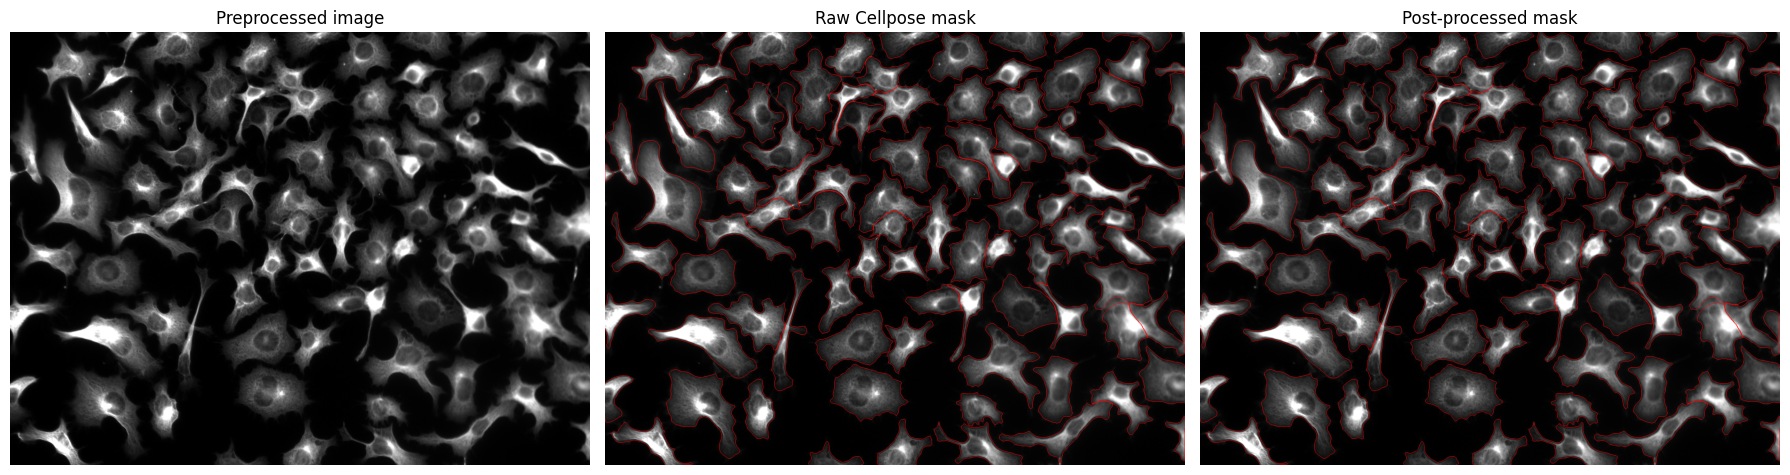

In [10]:

if SHOW_MATPLOTLIB:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(single_result["proc_img"], cmap="gray")
    axes[0].set_title("Preprocessed image")
    axes[0].axis("off")

    axes[1].imshow(overlay_boundaries(single_result["proc_img"], single_result["pred_mask_raw"]))
    axes[1].set_title("Raw Cellpose mask")
    axes[1].axis("off")

    axes[2].imshow(overlay_boundaries(single_result["proc_img"], single_result["pred_mask_post"]))
    axes[2].set_title("Post-processed mask")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

if SHOW_NAPARI and HAS_NAPARI:
    viewer = napari.Viewer()
    viewer.add_image(single_result["proc_img"], name="image")
    viewer.add_labels(single_result["pred_mask_raw"], name="pred_raw")
    viewer.add_labels(single_result["pred_mask_post"], name="pred_post")
    napari.run()

## 10. All Image in Folder and All parameter combination

This runs the full pipeline over all images and all requested parameter combinations.

In [11]:

all_results = []
all_feature_tables = []

if RUN_SWEEP:
    combos = list(itertools.product(SWEEP_DIAMETERS, SWEEP_CELLPROB_THRESHOLDS, SWEEP_FLOW_THRESHOLDS))
    print(f"Running {len(combos)} parameter combinations on {len(image_files)} image(s)...")

    for img_path in image_files:
        gt_path = maybe_find_gt(img_path, GT_PATH)
        for diameter, cp, ft in combos:
            res = run_pipeline_on_image(
                img_path=img_path,
                gt_path=gt_path,
                save_root=SAVE_ROOT,
                diameter=diameter,
                cellprob_threshold=cp,
                flow_threshold=ft,
                model_type=MODEL_TYPE,
                use_gpu=USE_GPU,
                apply_postprocess=True,
            )

            row = {
                "image_name": stem(img_path),
                "diameter": diameter,
                "cellprob_threshold": cp,
                "flow_threshold": ft,
                **{f"raw_{k}": v for k, v in res["image_metrics_raw"].items()},
                **{f"post_{k}": v for k, v in res["image_metrics_post"].items()},
                "out_dir": res["out_dir"],
            }
            all_results.append(row)

            all_feature_tables.append(res["features_raw"])
            all_feature_tables.append(res["features_post"])

    summary_df = pd.DataFrame(all_results)
    feature_df = pd.concat(all_feature_tables, ignore_index=True) if all_feature_tables else pd.DataFrame()

    summary_path = os.path.join(SAVE_ROOT, "sweep_summary.csv")
    features_path = os.path.join(SAVE_ROOT, "all_features.csv")
    summary_df.to_csv(summary_path, index=False)
    feature_df.to_csv(features_path, index=False)

    print("Saved:", summary_path)
    print("Saved:", features_path)
    display(summary_df.head())
else:
    summary_df = pd.DataFrame()
    feature_df = pd.DataFrame()

model_type argument is not used in v4.0.1+. Ignoring this argument...


Running 2 parameter combinations on 1 image(s)...
Resizing GT from (520, 696) to (1040, 1392)


model_type argument is not used in v4.0.1+. Ignoring this argument...


Resizing GT from (520, 696) to (1040, 1392)
Saved: ./results_cellpose/sweep_summary.csv
Saved: ./results_cellpose/all_features.csv


,image_name,diameter,cellprob_threshold,flow_threshold,raw_image_dice_binary,raw_image_iou_binary,raw_n_pred_instances,raw_n_gt_instances,post_image_dice_binary,post_image_iou_binary,post_n_pred_instances,post_n_gt_instances,out_dir
0,F01_120w1,30,-2.0,0.2,0.88473,0.793288,78,9,0.884730,0.793287,78,9,./results_cellpose/F01_120w1/d30_cp-2.0_ft0.2
1,F01_120w1,30,0.0,0.2,0.93568,0.879135,88,9,0.935737,0.879234,88,9,./results_cellpose/F01_120w1/d30_cp0.0_ft0.2


## 11. Inspect the best settings


In [12]:

if not summary_df.empty and "post_image_dice_binary" in summary_df.columns:
    best_summary = summary_df.sort_values(
        by=["post_image_dice_binary", "post_image_iou_binary"],
        ascending=False
    )
    display(best_summary.head(10))
else:
    print("No sweep summary with GT-based image metrics available yet.")

,image_name,diameter,cellprob_threshold,flow_threshold,raw_image_dice_binary,raw_image_iou_binary,raw_n_pred_instances,raw_n_gt_instances,post_image_dice_binary,post_image_iou_binary,post_n_pred_instances,post_n_gt_instances,out_dir
1,F01_120w1,30,0.0,0.2,0.93568,0.879135,88,9,0.935737,0.879234,88,9,./results_cellpose/F01_120w1/d30_cp0.0_ft0.2
0,F01_120w1,30,-2.0,0.2,0.88473,0.793288,78,9,0.884730,0.793287,78,9,./results_cellpose/F01_120w1/d30_cp-2.0_ft0.2


# 12. Random forest for mask quality